TensorFlow Version: 2.19.0

Dataset Shape: (50000, 32, 32, 3)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,347 (52.14 KB)

 Trainable params: 13,347 (52.14 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 133s 336ms/step - loss: 0.0150 - val_loss: 0.0085
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 129s 329ms/step - loss: 0.0074 - val_loss: 0.0067
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 128s 328ms/step - loss: 0.0060 - val_loss: 0.0061
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 125s 319ms/step - loss: 0.0055 - val_loss: 0.0052
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 142s 319ms/step - loss: 0.0051 - val_loss: 0.0050
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 144s 324ms/step - loss: 0.0049 - val_loss: 0.0047
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 143s 327ms/step - loss: 0.0047 - val_loss: 0.0046
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 131s 336ms/step - loss: 0.0046 - val_loss: 0.0045
Epoch 9/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 141s 334ms/step - loss: 0.0045 - val_loss: 0.0045
Epoch 10/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 136s 319ms/step - loss: 0.0044 - val_loss: 0.0043


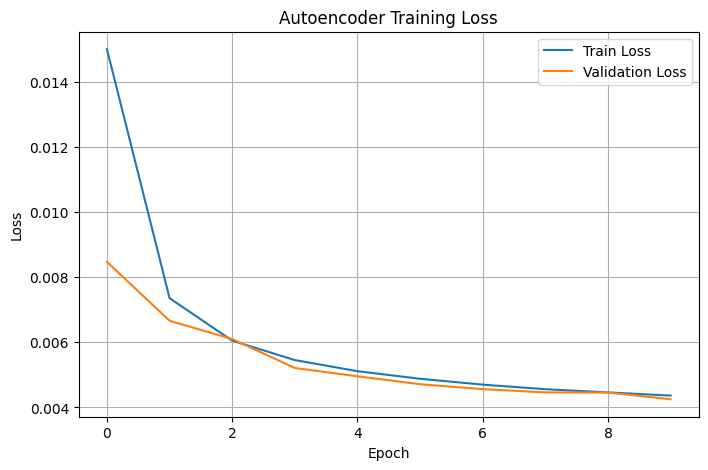

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step


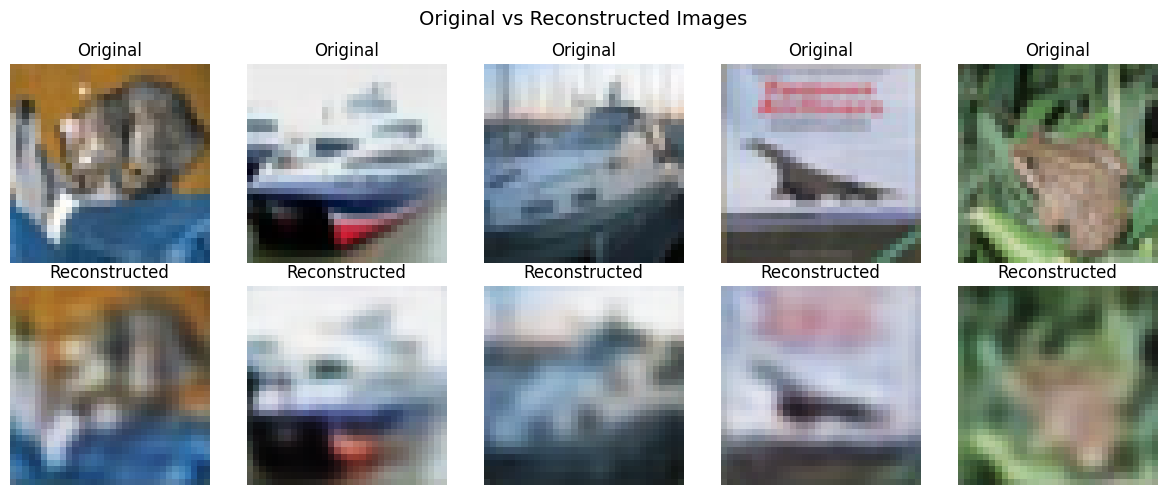

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


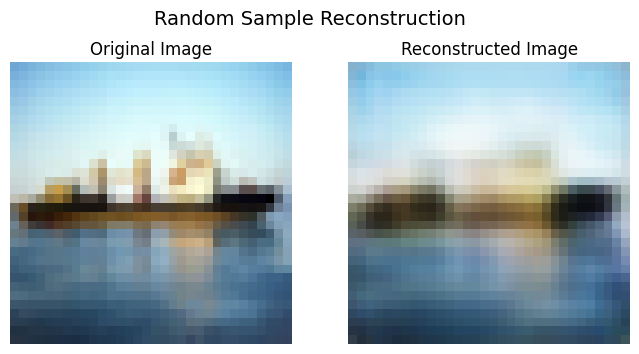

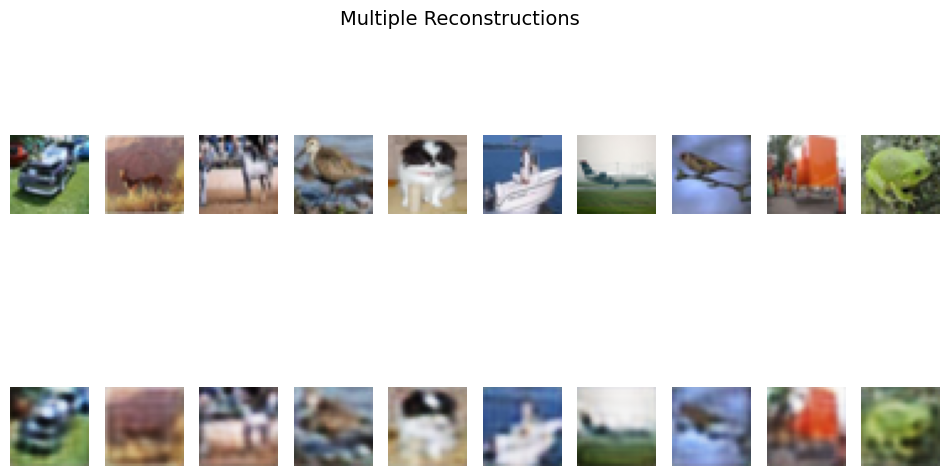

In [4]:
# ==========================================
# STEP 1: Import Libraries
# ==========================================
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow Version:", tf.__version__)

# ==========================================
# STEP 2: Load Dataset
# ==========================================
(x_train, _), (x_test, _) = keras.datasets.cifar10.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

print("\nDataset Shape:", x_train.shape)

# ==========================================
# STEP 3: Build CNN Autoencoder (IMPROVED)
# ==========================================
input_img = keras.Input(shape=(32, 32, 3))

# -------- Encoder --------
x = keras.layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = keras.layers.MaxPooling2D((2,2), padding='same')(x)

x = keras.layers.Conv2D(16, (3,3), activation='relu', padding='same')(x)
encoded = keras.layers.MaxPooling2D((2,2), padding='same')(x)

# -------- Decoder --------
x = keras.layers.Conv2D(16, (3,3), activation='relu', padding='same')(encoded)
x = keras.layers.UpSampling2D((2,2))(x)

x = keras.layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = keras.layers.UpSampling2D((2,2))(x)

decoded = keras.layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

# Model
autoencoder = keras.Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

# ==========================================
# STEP 4: Train Model
# ==========================================
history = autoencoder.fit(
    x_train, x_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test, x_test)
)

# ==========================================
# STEP 5: Plot Loss Graph (MATCH STYLE)
# ==========================================
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Autoencoder Training Loss')
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# STEP 6: Reconstruction
# ==========================================
decoded_imgs = autoencoder.predict(x_test)

# ==========================================
# STEP 7: Show Original vs Reconstructed (CLEAN VIEW)
# ==========================================
n = 5
plt.figure(figsize=(12,5))

for i in range(n):
    # Original
    plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i])
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.title("Reconstructed")
    plt.axis('off')

plt.suptitle("Original vs Reconstructed Images", fontsize=14)
plt.tight_layout()
plt.show()

# ==========================================
# STEP 8: Random Image Reconstruction
# ==========================================
idx = np.random.randint(0, len(x_test))

original = x_test[idx]
reconstructed = autoencoder.predict(original.reshape(1,32,32,3))

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(original)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(reconstructed[0])
plt.title("Reconstructed Image")
plt.axis('off')

plt.suptitle("Random Sample Reconstruction", fontsize=14)
plt.show()

# ==========================================
# STEP 9: Multiple Random Samples (LIKE YOUR FILE STYLE)
# ==========================================
plt.figure(figsize=(12,6))

for i in range(10):
    idx = np.random.randint(0, len(x_test))

    # Original
    plt.subplot(2,10,i+1)
    plt.imshow(x_test[idx])
    plt.axis('off')

    # Reconstructed
    plt.subplot(2,10,i+11)
    plt.imshow(decoded_imgs[idx])
    plt.axis('off')

plt.suptitle("Multiple Reconstructions", fontsize=14)
plt.show()